# Práctica Clase 1 - Transformers
Implementación de Atención Escalada por Producto Punto y Atención Multicabeza

In [8]:
# Importar dependencias
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Definir la semilla pra reproducibilidad

SEED = 666
torch.manual_seed(SEED)
np.random.seed(SEED)

In [10]:
# Implementar la atención escalda por producto punto

def scaled_dot_product_attention(Q,K,V, mask = None, dropout = None):
    """Calcula la atención escalada por producto punto

    Args:
        Q (_type_): Tensor de consultas
        K (_type_): Tensor de claves
        V (_type_): Tensor de valores
        mask (_type_, optional): Tensor opcional con valores 0 o -inf para enmascarar. Por defecto ninguno
        dropout (_type_, optional): Capa de dropout opcional para aplicar después de softmax. Por defecto ninguna
    Returns:
        output: Tensor con los pesos de atención ponderada
        attention_weights: Tensor con los pesos de atención
    """
    d_k = Q.size(-1)
    scores = torch.matmul(Q,K.transpose(-2,-1))/torch.sqrt(torch.tensor(d_k, dtype=torch.float32))
    
    # Aplicamos la máscara
    if mask is not None:
        scores = scores + mask
    
    # Aplicamos softmax sobre la última dimensión
    
    attention_weights = F.softmax(scores, dim= -1)
    
    # Aplicamos dropout
    
    if dropout is not None:
        attention_weights = dropout(attention_weights)
        
    # Multiplicamos por V
    
    output = torch.matmul(attention_weights, V)
    
    return output, attention_weights
    
    

In [11]:
# Implementación de la atención multi-cabeza

class MultiHeadAttention(nn.Module):
    """Capa de Atención Multi-Cabeza implementada desde 0
    """
    
    def __init__(self, d_model, num_heads, dropout = 0.1):
        """Contructor de la clase
        Args:
            d_model (_type_): Dimensión del modelo
            num_heads (_type_): Número de cabezas
            dropout (float, optional): Probabilidad de dropout. Por defecto en 0.1.
        """
        super(MultiHeadAttention, self).__init__()
        
        assert d_model % num_heads == 0, "d_model debe ser divisible por num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model//num_heads
        
        # Proyecciones lineales Q, K, V
        
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        
        # Proyecciones lineales finales
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        
        # Dropout
        self.dropout = nn.Dropout(dropout)      
        
    def forward(self, Q, K, V, mask = None):
        """Método para el forward pass

        Args:
            Q (_type_): Tensor de consultas
            K (_type_): Tensor de claves
            V (_type_): Tensor de valores
            mask (_type_, optional): Tensor opcional con valores 0 o -inf para enmascarar. Por defecto ninguno
        Returns:
            output: Tensor con los pesos de atención ponderada
            attention_weights: Tensor con los pesos de atención
        """
            
        batch_size = Q.size(0)
            
        Q = self.W_q(Q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1,2)
        K = self.W_k(K).view(batch_size, -1, self.num_heads, self.d_k).transpose(1,2)
        V = self.W_v(V).view(batch_size, -1, self.num_heads, self.d_k).transpose(1,2)
            
        # Aplicamos atencion escalada a cada cabeza
            
        if mask is not None:
            if mask.dim() == 2: # seq_len_q, seq_len_k
                mask = mask.unsqueeze(0).unsqueeze(1) # 1, 1, seq_len_q, seq_len_k
            elif mask.dim() == 3: # batch_size, seq_len_q, seq_len_k
                mask = mask.unsqueeze(1) # batch_size, 1, seq_len_q, seq_len_k
            
        # Llamamos a la función de atención
            
        attn_ouptut, attention_weights = scaled_dot_product_attention(Q,K,V, mask=mask, dropout= self.dropout)
            
        # Concatenamos las cabezas
            
        attn_ouptut = attn_ouptut.transpose(1,2).contiguous().view(batch_size, -1, self.d_model)
            
        # Proyección final
            
        output = self.W_o(attn_ouptut)
            
        return output, attention_weights
            

In [ ]:
# Prueba con una secuencia sintética

# Definir los parámetros

d_model = 64
num_heads = 8
seq_len = 10
batch_size = 2

# Creamos los datos sintéticos

X = torch.randn(batch_size, seq_len, d_model)

# Instanciar la capa de atención

mha = MultiHeadAttention(d_model, num_heads, dropout=0.0) # Dropout en 0.0 para una visualización clara

# Pasar por la atención Q, K, V

output, attention_weights = mha(X,X,X, mask = None) 


In [13]:
print(f"Forma de la salida: {output.shape}")
print(f"Forma de los pesos de atención: {attention_weights.shape}")

Forma de la salida: torch.Size([2, 10, 64])
Forma de los pesos de atención: torch.Size([2, 4, 10, 10])


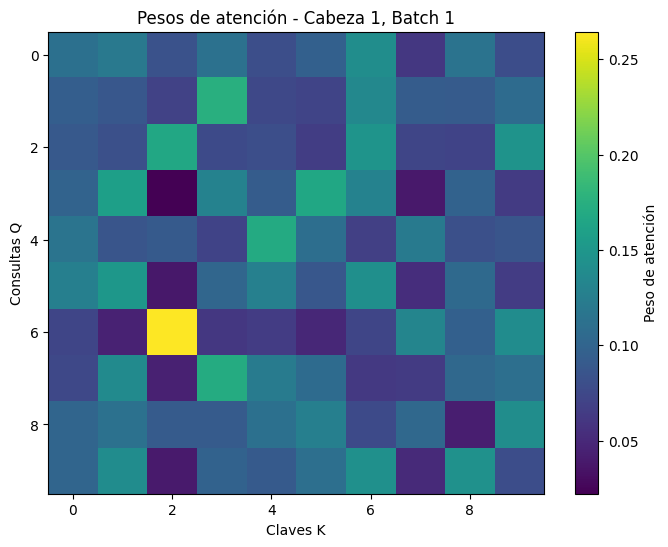

In [15]:
# Visualización de los pesos con un heatmap

# Tomamos el primer elemento del batch y la primera cabeza para visualizar

sample_weights = attention_weights[0, 0, :, :].detach().cpu().numpy()

plt.figure(figsize=(8, 6))
plt.imshow(sample_weights, cmap='viridis', aspect='auto')
plt.colorbar(label='Peso de atención')
plt.title('Pesos de atención - Cabeza 1, Batch 1')
plt.xlabel('Claves K')
plt.ylabel('Consultas Q')
plt.show()

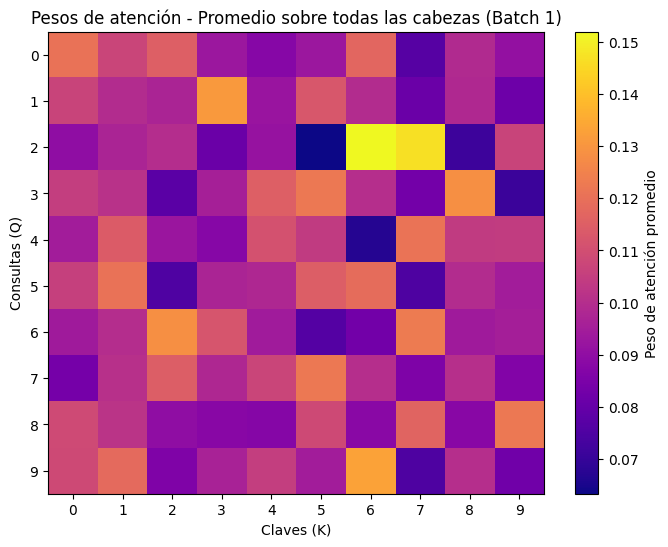

In [17]:
# También podemos visualizar la atención promedio de todas las cabezas para el batch

avg_attention = attention_weights[0].mean(0).detach().numpy()  # Promedio sobre cabezas

plt.figure(figsize=(8, 6))
plt.imshow(avg_attention, cmap='plasma', aspect='auto')
plt.colorbar(label='Peso de atención promedio')
plt.title('Pesos de atención - Promedio sobre todas las cabezas (Batch 1)')
plt.xlabel('Claves (K)')
plt.ylabel('Consultas (Q)')
plt.xticks(range(seq_len))
plt.yticks(range(seq_len))
plt.grid(False)
plt.show()

Máscara causal (primeros 5x5):
tensor([[nan, -inf, -inf, -inf, -inf],
        [nan, nan, -inf, -inf, -inf],
        [nan, nan, nan, -inf, -inf],
        [nan, nan, nan, nan, -inf],
        [nan, nan, nan, nan, nan]])


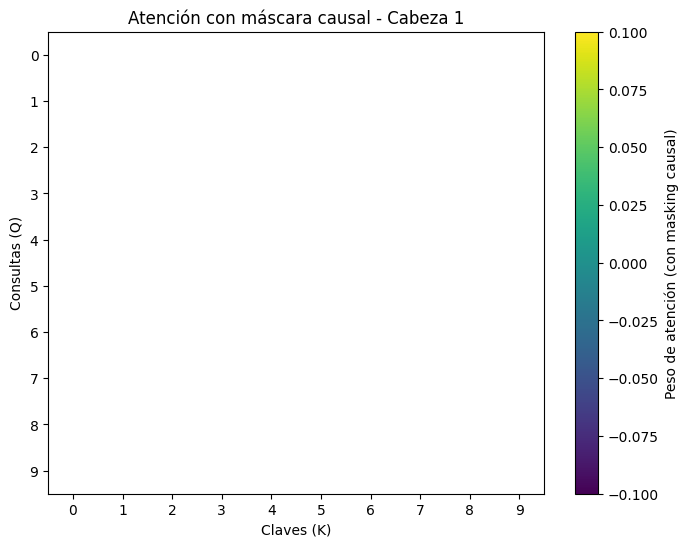

In [18]:
# Modificar la función "scaled_dot_product_attention"  para que acepte una máscara de tipo 'look-ahead' (causal) para el decoder.

def create_causal_mask(seq_len):
    # Crea una matriz de -inf en la parte superior derecha (triangular superior)
    # y 0 en la parte inferior izquierda (incluyendo la diagonal).
    mask = torch.full((seq_len, seq_len), float('-inf'))
    # torch.tril: mantiene la parte inferior (incluyendo diagonal) y pone 0 en el resto.
    # Queremos -inf en el triángulo superior, así que hacemos lo contrario:
    # Creamos una matriz de ceros y ponemos -inf donde i < j.
    mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1) * float('-inf')
    # mask tiene -inf en i<j y 0 en i>=j
    return mask

# Probar la máscara
causal_mask = create_causal_mask(seq_len)
print("Máscara causal (primeros 5x5):")
print(causal_mask[:5, :5])

# Aplicar la máscara en la atención
output_masked, attn_masked = mha(X, X, X, mask=causal_mask)

# Visualizar los pesos con máscara (cabeza 1, batch 1)
plt.figure(figsize=(8, 6))
plt.imshow(attn_masked[0, 0].detach().numpy(), cmap='viridis', aspect='auto')
plt.colorbar(label='Peso de atención (con masking causal)')
plt.title('Atención con máscara causal - Cabeza 1')
plt.xlabel('Claves (K)')
plt.ylabel('Consultas (Q)')
plt.xticks(range(seq_len))
plt.yticks(range(seq_len))
plt.grid(False)
plt.show()